# End-of-Month Auto Investment Plan: QQQ / BIL / GLD

Simulate a **monthly $1,000 auto investment plan (AIP)** into an equal-weight
3-ETF portfolio, rebalanced at the end of each month.

This notebook demonstrates:
- `run_aip()` for dollar-cost averaging (DCA) backtesting
- Comparison of **lump-sum** vs **AIP** investing
- AIP-specific metrics: `total_contributions`, `contribution_count`
- Full results API: summary, plots, trades

**Offline mode**: Uses local CSV files from `tests/data/` — no network required.

In [1]:
from pathlib import Path

import tiportfolio as ti

# Offline CSV data mapping — pre-downloaded YFinance CSVs (2018-2024)
_DATA_DIR = Path("../../tests/data")

CSV_DATA: dict[str, str] = {
    "QQQ": str(_DATA_DIR / "qqq_2018_2024_yf.csv"),
    "BIL": str(_DATA_DIR / "bil_2018_2024_yf.csv"),
    "GLD": str(_DATA_DIR / "gld_2018_2024_yf.csv"),
}

TICKERS = ["QQQ", "BIL", "GLD"]
START = "2019-01-01"
END = "2024-12-31"
MONTHLY_AIP = 1000  # $1,000 per month

## 1. Load Data

In [2]:
data = ti.fetch_data(TICKERS, start=START, end=END, csv=CSV_DATA)

# Quick peek at the data shape
for ticker, df in data.items():
    print(f"{ticker}: {df.shape[0]} rows, {df.index[0].date()} → {df.index[-1].date()}")

QQQ: 1760 rows, 2018-01-02 → 2024-12-30
BIL: 1760 rows, 2018-01-02 → 2024-12-30
GLD: 1760 rows, 2018-01-02 → 2024-12-30


## 2. Define Strategy & Run AIP Backtest

The algo stack follows the **Signal → Select → Weigh → Action** pattern:
- **Signal.Monthly()** — rebalance on the last trading day of each month
- **Select.All()** — include all tickers
- **Weigh.Equally()** — equal-weight allocation (1/3 each)
- **Action.Rebalance()** — execute trades to match target weights

`run_aip()` works exactly like `run()`, but injects `monthly_aip_amount` into
the portfolio on the last trading day of each month **before** the algo stack fires.

In [3]:
portfolio = ti.Portfolio(
    "aip_equal_weight",
    [
        ti.Signal.Monthly(),
        ti.Select.All(),
        ti.Weigh.Equally(),
        ti.Action.Rebalance(),
    ],
    TICKERS,
)

result_aip = ti.run_aip(ti.Backtest(portfolio, data), monthly_aip_amount=MONTHLY_AIP)

## 3. AIP Results Overview

The summary includes two AIP-specific metrics:
- **total_contributions** — total cash injected over the backtest period
- **contribution_count** — number of monthly injections

In [4]:
result_aip.summary()

,value
sharpe,2.433
calmar,4.494
sortino,4.862
max_drawdown,-0.105
cagr,0.470
risk_free_rate,0.040
total_return,13.736
kelly,16.625
final_value,147355.743
total_fee,4.451


In [5]:
result_aip.plot_interactive()

In [6]:
result_aip.full_summary()

,value
sharpe,2.433
calmar,4.494
sortino,4.862
max_drawdown,-0.105
cagr,0.470
risk_free_rate,0.040
total_return,13.736
kelly,16.625
final_value,147355.743
total_fee,4.451


## 4. Detailed Exploration

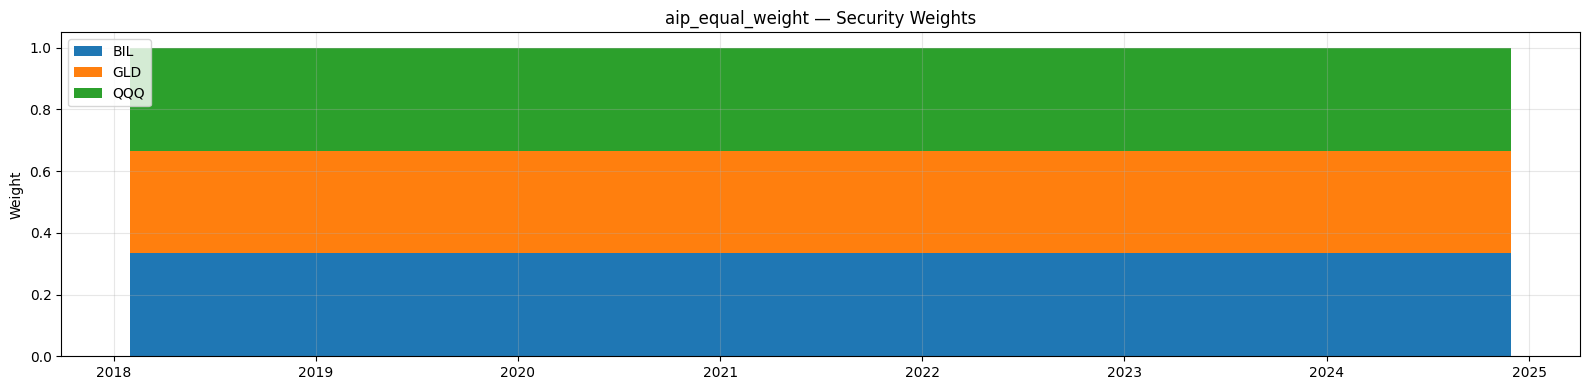

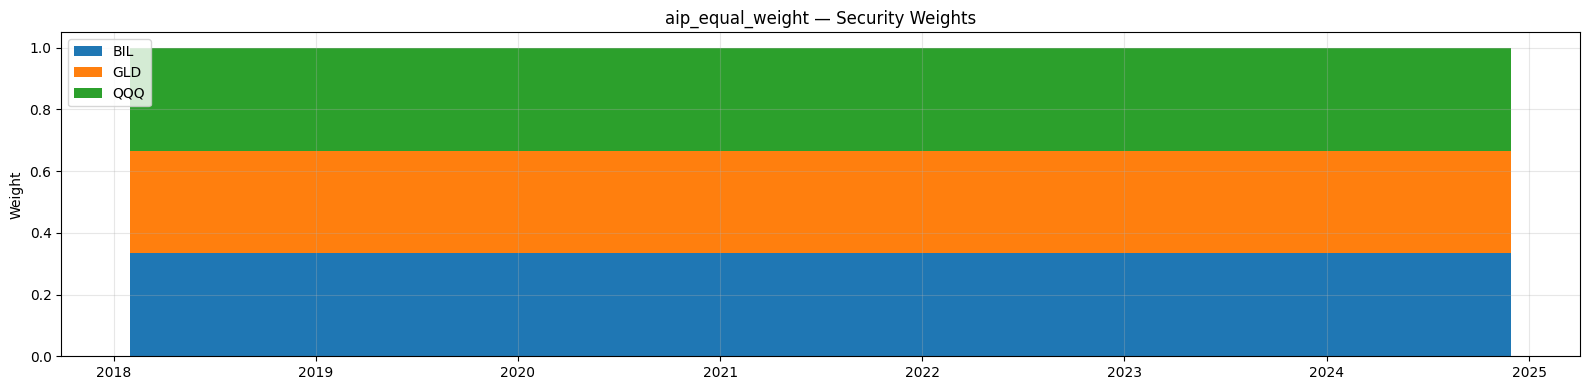

In [7]:
result_aip[0].plot_security_weights()

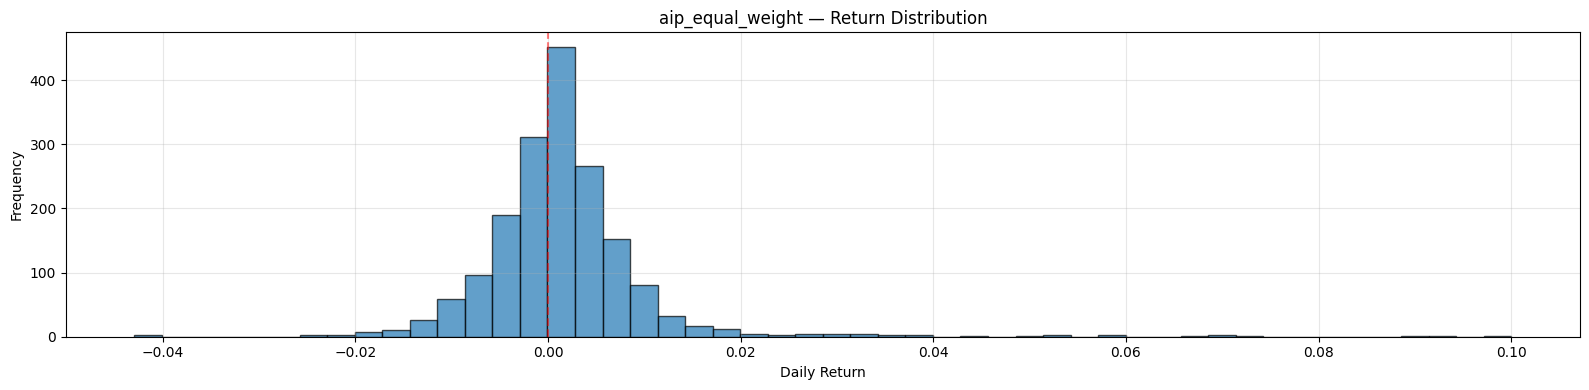

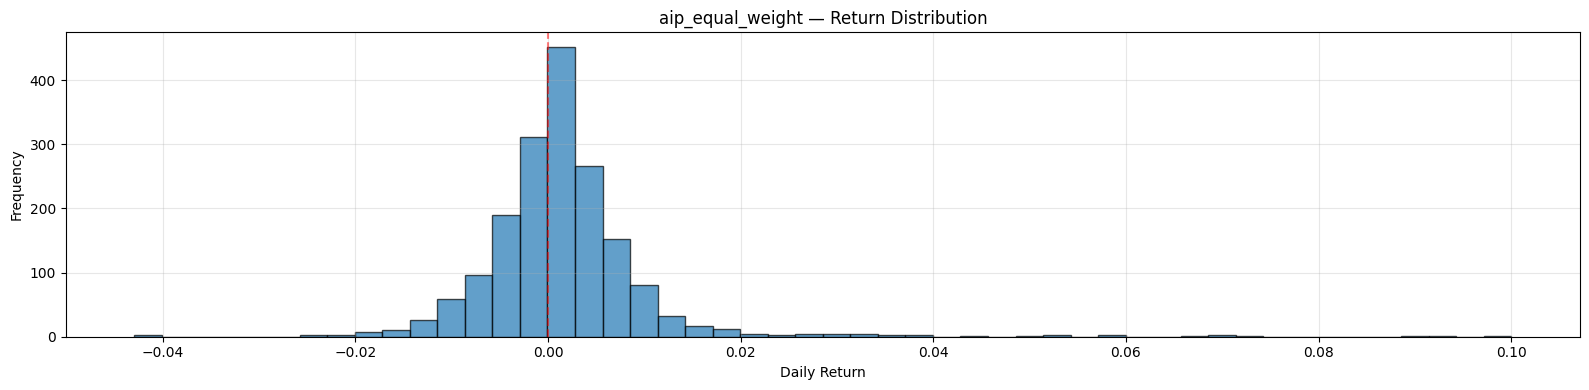

In [8]:
result_aip[0].plot_histogram()

In [9]:
print(f"Total trades: {len(result_aip[0].trades)}")
result_aip[0].trades.sample(5)

Total trades: 249


,date,portfolio,ticker,qty_before,qty_after,delta,price,fee,equity_before,equity_after
99,2020-10-30 04:00:00+00:00,aip_equal_weight,QQQ,68.563040,71.156063,2.593023,260.940948,0.009076,55702.591735,55702.573412
100,2020-10-30 04:00:00+00:00,aip_equal_weight,BIL,236.539797,237.984788,1.444991,78.019821,0.005057,55702.591735,55702.573412
101,2020-10-30 04:00:00+00:00,aip_equal_weight,GLD,104.182337,105.377587,1.195250,176.199997,0.004183,55702.591735,55702.573412
75,2020-02-28 05:00:00+00:00,aip_equal_weight,QQQ,63.782099,68.085152,4.303053,198.583481,0.015061,40561.759451,40561.740485
76,2020-02-28 05:00:00+00:00,aip_equal_weight,BIL,173.305866,173.586674,0.280808,77.889542,0.000983,40561.759451,40561.740485
0,2018-01-31 05:00:00+00:00,aip_equal_weight,QQQ,0.000000,22.807553,22.807553,160.765457,0.079826,11000.000000,10999.648423
1,2018-01-31 05:00:00+00:00,aip_equal_weight,BIL,0.000000,48.918592,48.918592,74.954460,0.171215,11000.000000,10999.648423
2,2018-01-31 05:00:00+00:00,aip_equal_weight,GLD,0.000000,28.724376,28.724376,127.650002,0.100535,11000.000000,10999.648423
162,2022-07-29 04:00:00+00:00,aip_equal_weight,QQQ,91.555831,85.137145,-6.418686,308.578369,0.022465,78814.444451,78814.331111
163,2022-07-29 04:00:00+00:00,aip_equal_weight,BIL,321.675593,336.547751,14.872158,78.061676,0.052053,78814.444451,78814.331111


## 5. Lump-Sum vs AIP Comparison

Compare the AIP strategy against a **lump-sum** approach where the full
$10,000 initial capital is invested on day one with no further contributions.

This is the classic DCA vs lump-sum debate — lump-sum typically wins in
rising markets, but AIP reduces timing risk and is more realistic for
regular savers.

In [10]:
# Lump-sum: same strategy, no monthly contributions
result_lump = ti.run(ti.Backtest(portfolio, data))

In [11]:
aip_summary = result_aip.summary()
lump_summary = result_lump.summary()

print("=== Lump-Sum vs AIP ===")
print(f"{'Metric':<25} {'Lump-Sum':>12} {'AIP':>12}")
print("-" * 50)
for metric in ["final_value", "cagr", "sharpe", "sortino", "max_drawdown", "total_return"]:
    lv = lump_summary.loc[metric, "value"]
    av = aip_summary.loc[metric, "value"]
    print(f"{metric:<25} {lv:>12.3f} {av:>12.3f}")

print()
print(f"{'AIP total_contributions':<25} {'':>12} {aip_summary.loc['total_contributions', 'value']:>12.0f}")
print(f"{'AIP contribution_count':<25} {'':>12} {aip_summary.loc['contribution_count', 'value']:>12.0f}")

=== Lump-Sum vs AIP ===
Metric                        Lump-Sum          AIP
--------------------------------------------------
final_value                  19951.667   147355.743
cagr                             0.104        0.470
sharpe                           0.655        2.433
sortino                          0.875        4.862
max_drawdown                    -0.162       -0.105
total_return                     0.995       13.736

AIP total_contributions                       84000
AIP contribution_count                           84


## 6. Equity Curve Overlay

Plot both strategies on the same chart. Note that the AIP curve grows much
larger in absolute terms because of the continuous cash contributions — the
portfolio is accumulating capital over time.

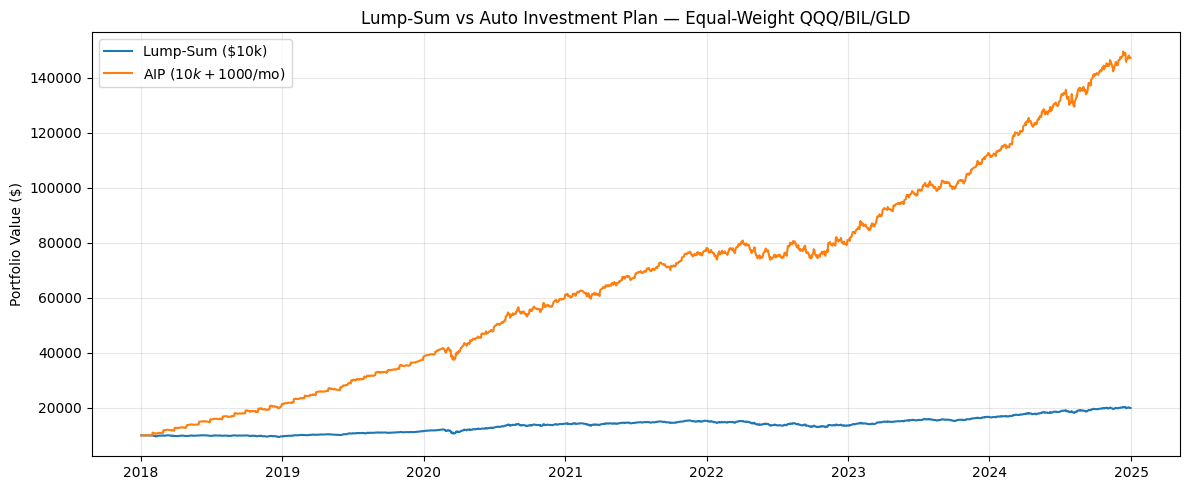

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(result_lump[0].equity_curve, label="Lump-Sum ($10k)", linewidth=1.5)
ax.plot(result_aip[0].equity_curve, label=f"AIP ($10k + ${MONTHLY_AIP}/mo)", linewidth=1.5)
ax.set_title("Lump-Sum vs Auto Investment Plan — Equal-Weight QQQ/BIL/GLD")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()